In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub

env: CUPY_ACCELERATORS=cutensor,cub


In [2]:
import tensorly as tl
import plotly.io as pio
#pio.renderers.default = 'iframe'
tl.set_backend('numpy')
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')

TensorLy backend: numpy


In [3]:
from moabb.datasets import *
from moabb.paradigms import P300

tmin=-0.2
dataset = BNCI2014_008()
paradigm = P300(tmin=-0.2)
epochs, y, meta = paradigm.get_data(dataset, return_epochs=True)
X = epochs.get_data()
groups=meta['subject']
X = tl.tensor(X)
X.shape

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), -0.199 – 1 s (baseline off), ~79.0 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), -0.199 – 1 s (baseline off), ~79.0 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), -0.199 – 1 s (baseline off), ~79.0 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: 

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), -0.199 – 1 s (baseline off), ~79.0 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


Adding metadata with 3 columns
33600 matching events found
No baseline correction applied


(33600, 8, 308)

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from hoda.classification import SelectFCutoff
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf = make_pipeline(
    FunctionTransformer(tl.to_numpy),
    PCA(n_components=None, whiten=True),
    SelectFCutoff(cutoff=1),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

In [5]:
from sklearn.model_selection import StratifiedGroupKFold
from hoda.classification import BTTDACV
from hoda.hoda import BTTDA

cv = StratifiedGroupKFold(n_splits=5)

hoda_params=  dict(
    max_iter=64,
    toeplitz=(1,),
    taper=False,
    verbose=True,
)


bttdacv_params = dict(
    hoda_params=hoda_params,
    verbose=True,
    cv=cv,
    n_jobs=-1,
    clf = clf,
)

bttdacv = BTTDACV(
    max_n_blocks=2,
    fixed_n_blocks=True,
    thetas=[0,0.1,0.2,0.3,0.4,0.5,0.6, 0.7, 0.8, 0.9,1],    
    **bttdacv_params
)

    

In [6]:
import joblib
from joblib import Parallel, delayed
import distributed
from hpc import create_cluster, create_client, TIMEOUT


with create_cluster(cluster='wice_sapphirerapids') as cluster, create_client(cluster) as client:
    with joblib.parallel_backend('dask', wait_for_workers_timeout=TIMEOUT): 
        client.wait_for_workers(5*11)
        bttdacv.fit(X,y, groups=groups)



[Parallel(n_jobs=-1)]: Using backend DaskDistributedBackend with 630 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 out of  55 | elapsed:  1.6min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done  55 out of  55 | elapsed: 23.4min finished


Fitting BTTDA with theta=0.3, n_blocks=2
Fitting block 1/2...


Forward model : 100%|██████████| 63/63 [00:17<00:00,  3.54it/s]


Fitting block 2/2...


Forward model :  44%|████▍     | 28/63 [00:08<00:10,  3.45it/s]


2

In [21]:
bttdacv.blocks_[0].theta

0.3

In [22]:
bttdacv.blocks_[1].theta

0.3

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


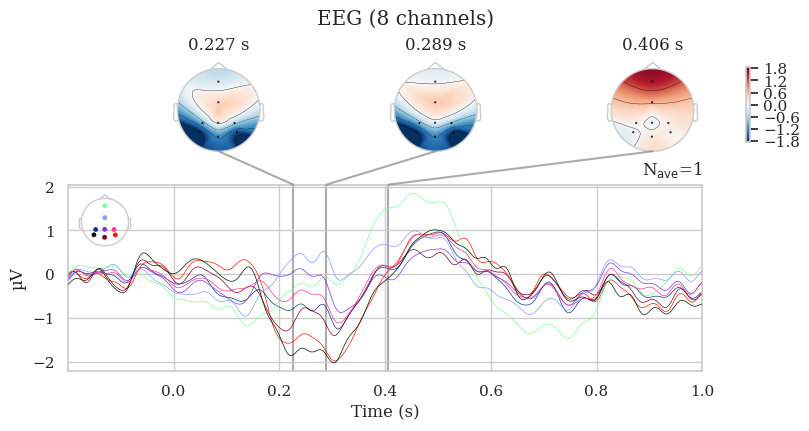

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


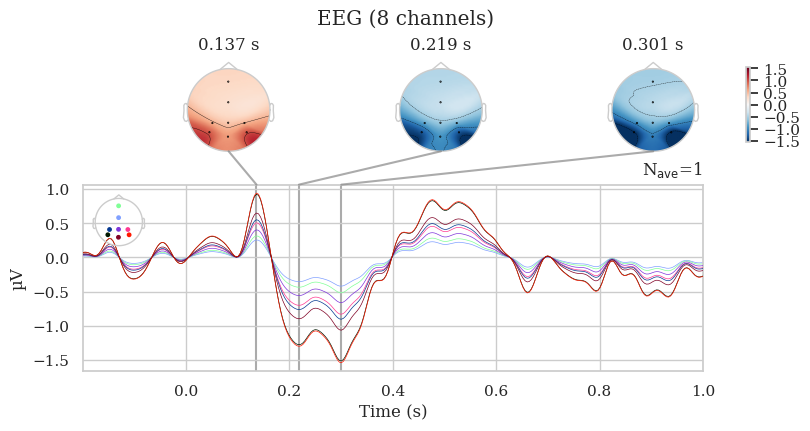

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


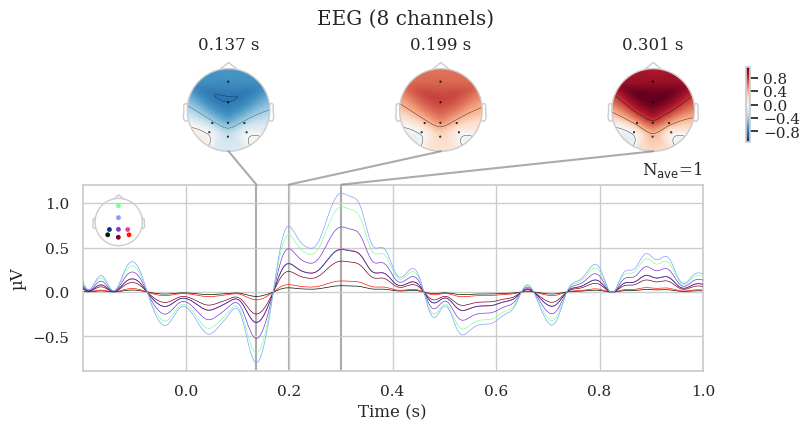

In [24]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import plotly.express as px
from mne import EvokedArray
%matplotlib inline

plot_kwargs=dict(
    ts_args=dict(
        #ylim=dict(eeg=[-2,2.5])
    )
)

target = X[y=='Target'].mean(axis=0)
non_target = X[y=='NonTarget'].mean(axis=0)
contrast = target - non_target
evoked = EvokedArray(tl.to_numpy(contrast), epochs.info, tmin=tmin)
evoked = evoked.apply_baseline((None, 0))
evoked.save(f'results/interpretability/erp_contrast_ave.fif')
evoked.plot_joint(**plot_kwargs)

X_prev = tl.zeros_like(X)
for bi,b in enumerate(bttdacv.blocks_):
    Xt = bttdacv.transform(X, n_blocks=bi+1)
    Xr = bttdacv.inv_transform(Xt, n_blocks=bi+1) - X_prev
    X_prev = Xr
    
    target = Xr[y=='Target'].mean(axis=0)
    non_target = Xr[y=='NonTarget'].mean(axis=0)
    contrast = target - non_target
    evoked = EvokedArray(tl.to_numpy(contrast), epochs.info, tmin=tmin)
    evoked = evoked.apply_baseline((None,0))
    evoked.save(f'results/interpretability/erp_contrast_block-{bi}_ave.fif')
    evoked.plot_joint(**plot_kwargs)